C:\Users\Xiaohang\AppData\Local\Temp\ipykernel_7444\1387439864.py:93: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().set_visible(False)


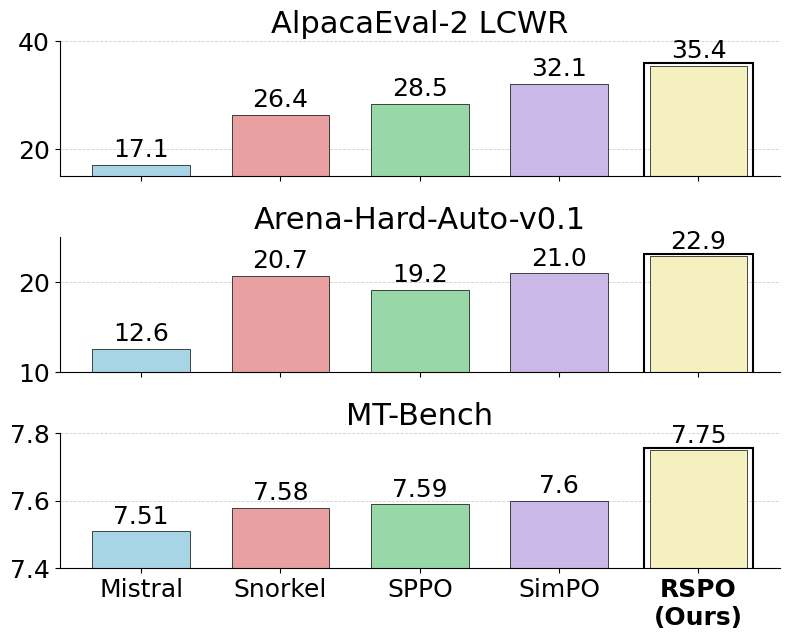

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

# Data from your table
methods_full = [
    "Mistral-7B-Instruct",
    "Snorkel (Iterative DPO)",
    "SPPO Iter3",
    "SimPO",
    "RSPO (IS-For.+Rev.) Iter3 (Ours)",
]


def simplify_name(name):
    """取第一个 ' ' 或 '-' 之前的部分，若含 (Ours) 则保留为 'xxx (Ours)'"""
    pos_s = name.find(" ")
    pos_d = name.find("-")
    if pos_s == -1:
        pos_s = len(name)
    if pos_d == -1:
        pos_d = len(name)
    first = min(pos_s, pos_d)
    base = name[:first] if first < len(name) else name
    if "(Ours)" in name or "(ours)" in name.lower():
        return f"{base} (Ours)"
    return base


methods = [simplify_name(m) for m in methods_full]

df = pd.DataFrame(
    {
        "AlpacaEval-2 LCWR": [17.1, 26.4, 28.5, 32.1, 35.4],
        "Arena-Hard-Auto-v0.1": [12.6, 20.7, 19.2, 21.0, 22.9],
        "MT-Bench": [7.51, 7.58, 7.59, 7.60, 7.75],
    },
    index=methods,
)

# 竖着排三个图，各自 y 轴范围按之前设定
benchmarks = list(df.columns)
ylim_by_benchmark = {
    "AlpacaEval-2 LCWR": (15, 40),
    "Arena-Hard-Auto-v0.1": (10, 25),
    "MT-Bench": (7.4, 7.8),
}
# 参考图的五色：浅蓝、浅粉、浅绿、浅紫、浅黄
colors = ["#A8D5E5", "#E8A0A0", "#98D8A8", "#C9B8E8", "#F5F0C0"]

fig, axes = plt.subplots(3, 1, figsize=(8, 6.5))

# 方法名展示：(Ours) 换行
def display_labels(names):
    return [m.replace(" (Ours)", "\n(Ours)") for m in names]

for i, (ax, col) in enumerate(zip(axes, benchmarks)):
    ser = df[col]
    x_pos = np.arange(len(ser))
    bars = ax.bar(x_pos, ser.values, width=0.7, color=colors, edgecolor="black", linewidth=0.5)
    for b, v in zip(bars, ser.values):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.02 * (ylim_by_benchmark[col][1] - ylim_by_benchmark[col][0]),
                f"{v}", ha="center", va="bottom", fontsize=18)
    ax.set_title(col, fontsize=22)
    ax.set_ylim(ylim_by_benchmark[col])
    ax.set_xticks(x_pos)
    if i < 2:
        ax.set_xticklabels([])  # 前两张图横轴名称删掉
    else:
        ax.set_xticklabels(display_labels(ser.index), fontsize=18, rotation=0)
        # RSPO (Ours) 对应刻度加粗
        for j, lbl in enumerate(ax.get_xticklabels()):
            if "(Ours)" in str(ser.index[j]):
                lbl.set_fontweight("bold")
    # ax.set_ylabel("LC Win Rate" if i == 0 else "Win Rate", fontsize=18)
    ax.tick_params(axis="y", labelsize=18)
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    # 最后一列 RSPO bar 加框（每张图只框自己的 bar，不拉通整图）
    last_bar = bars[-1]
    yrange = ylim_by_benchmark[col][1] - ylim_by_benchmark[col][0]
    pad_x, pad_y = 0.04, 0.02 * yrange
    rect = Rectangle((last_bar.get_x() - pad_x, 0), last_bar.get_width() + 2 * pad_x, last_bar.get_height() + pad_y,
                     linewidth=1.5, edgecolor="black", facecolor="none")
    ax.add_patch(rect)

# 只在第一个子图显示图例，避免重复
# axes[0].legend(loc="upper right", ncol=1, fontsize=18)
for ax in axes[1:]:
    ax.legend().set_visible(False)
plt.tight_layout()
plt.savefig("fig1.pdf")
plt.show()
